# A/B тесты

### 1. Реализую таблицу пользователь-группа и проверю что группы одинакового размера.

In [384]:
import pandas as pd
from scipy.stats import binomtest

likes = pd.read_csv('likes.csv')
views = pd.read_csv('views.csv')

In [385]:
likes.head()

,user_id,post_id,timestamp
0,128381,4704,1654030804
1,146885,1399,1654030816
2,50948,2315,1654030828
3,14661,673,1654030831
4,37703,1588,1654030833


In [386]:
views.head()

,user_id,exp_group,recommendations,timestamp
0,128381,control,[3644 4529 4704 5294 4808],1654030803
1,146885,test,[1399 1076 797 7015 5942],1654030811
2,50948,test,[2315 3037 1861 6567 4093],1654030825
3,37703,test,[2842 1949 162 1588 6794],1654030826
4,14661,test,[2395 5881 5648 3417 673],1654030829


In [387]:
user_group_counts = views.groupby('user_id')['exp_group'].nunique()

bad_users = user_group_counts[user_group_counts > 1].index

views = views[~views['user_id'].isin(bad_users)]
likes = likes[~likes['user_id'].isin(bad_users)]

In [388]:
views_control = views[views['exp_group'] == 'control'][['user_id', 'exp_group']]

In [389]:
views_control = views_control.drop_duplicates(subset=['user_id'])
views_control

,user_id,exp_group
0,128381,control
10,155358,control
11,157618,control
13,20451,control
14,147602,control
...,...,...
193131,11133,control
193156,90481,control
193172,100072,control
193258,36834,control


In [390]:
views_test = views[views['exp_group'] == 'test'][['user_id', 'exp_group']]

In [391]:
views_test = views_test.drop_duplicates(subset=['user_id'])
views_test

,user_id,exp_group
1,146885,test
2,50948,test
3,37703,test
4,14661,test
5,140763,test
...,...,...
193185,65732,test
193267,80500,test
193270,149686,test
193288,119630,test


In [392]:
len_all = len(views_control) + len(views_test)
len_control = len(views_control)
len_test = len(views_test)

In [393]:
binomtest(
    k=len_control,
    n=len_all,
    p=0.5)

BinomTestResult(k=32350, n=65009, alternative='two-sided', statistic=0.49762340598993987, pvalue=0.2270501563614752)

### 2. Посчитаю процент пользователей, которые сделали хотя бы один лайк за время эксперимента, без разбивки на группы.

In [394]:
all_users = pd.concat([views_test, views_control], ignore_index=True)[['user_id', 'exp_group']]

In [395]:
likes = likes[~likes['user_id'].isin(bad_users)]
grouped_likes = likes['user_id'].value_counts()
grouped_likes

user_id
80137     45
62950     44
86170     44
167241    42
155487    40
          ..
8930       1
162054     1
108892     1
133866     1
61624      1
Name: count, Length: 58167, dtype: int64

In [396]:
all_users_with_likes = all_users.merge(grouped_likes, on='user_id', how='left')

In [397]:
all_users_with_likes['count'] = all_users_with_likes['count'].fillna(0)
all_users_with_likes

,user_id,exp_group,count
0,146885,test,4.0
1,50948,test,5.0
2,37703,test,6.0
3,14661,test,11.0
4,140763,test,3.0
...,...,...,...
65004,11133,control,2.0
65005,90481,control,2.0
65006,100072,control,0.0
65007,36834,control,0.0


In [398]:
(len(all_users_with_likes[all_users_with_likes['count'] >= 1]) / len(all_users_with_likes)) * 100

89.47530341952653

### 3. Оценю 2 метрики на стат. значимость: доля пользователей с хотя бы одним лайком, число лайков на пользователя. 

In [399]:
counts_likes_test = all_users_with_likes[all_users_with_likes['exp_group'] == 'test']['count']
counts_likes_control = all_users_with_likes[all_users_with_likes['exp_group'] == 'control']['count']

In [400]:
len(counts_likes_test) + len(counts_likes_control)

65009

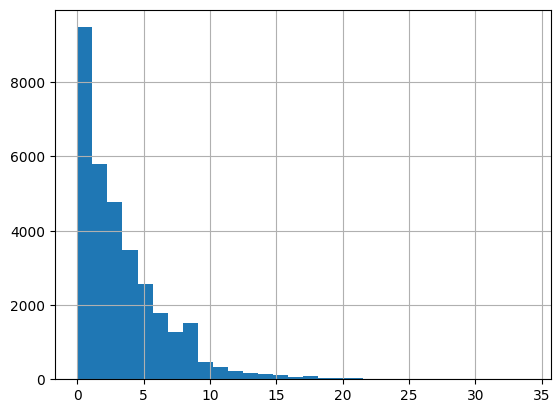

In [401]:
counts_likes_control.hist(bins=30);

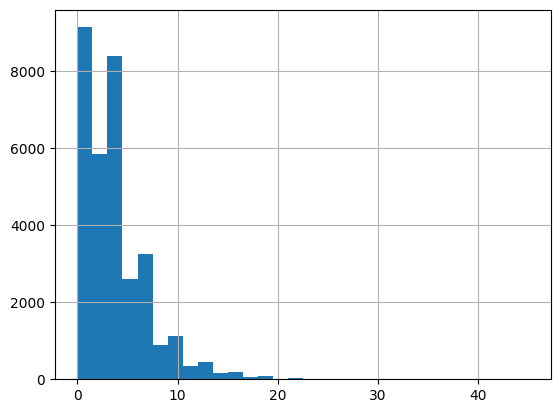

In [402]:
counts_likes_test.hist(bins=30);

In [403]:
counts_likes_control >= 1

32659     True
32660     True
32661     True
32662     True
32663     True
         ...  
65004     True
65005     True
65006    False
65007    False
65008     True
Name: count, Length: 32350, dtype: bool

In [404]:
counts_likes_test >= 1

0        True
1        True
2        True
3        True
4        True
         ... 
32654    True
32655    True
32656    True
32657    True
32658    True
Name: count, Length: 32659, dtype: bool

In [405]:
# test - control
print((sum(counts_likes_test >= 1) / len(counts_likes_test)) - (sum(counts_likes_control >= 1) / len(counts_likes_control)))

0.006846016395451238


In [413]:
from statsmodels.stats.proportion import proportions_ztest

count = [sum(counts_likes_test >= 1), sum(counts_likes_control >= 1)]
nobs = [len(counts_likes_test), len(counts_likes_control)]

statistic, p_value = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
statistic, p_value

(np.float64(2.8440248969682322), np.float64(0.00445475668548642))

*Различие статистически значимо*

In [407]:
# test - control
counts_likes_test.mean() - counts_likes_control.mean()

np.float64(0.10549902455578986)

In [408]:
from scipy.stats import mannwhitneyu

mannwhitneyu(counts_likes_test, counts_likes_control, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(538160577.0), pvalue=np.float64(2.958506279244197e-05))

*Различие также статистически значимо*

In [409]:
# Центр mannwhitneyu
(len(counts_likes_test) * len(counts_likes_control)) / 2

528259325.0

### 4. Посчитаю общий Hitrate для всех групп

In [419]:
import pandas as pd

likes_1 = pd.read_csv('likes.csv')
views_1 = pd.read_csv('views.csv')

In [420]:
likes_1.head()

,user_id,post_id,timestamp
0,128381,4704,1654030804
1,146885,1399,1654030816
2,50948,2315,1654030828
3,14661,673,1654030831
4,37703,1588,1654030833


In [421]:
views_1.head()

,user_id,exp_group,recommendations,timestamp
0,128381,control,[3644 4529 4704 5294 4808],1654030803
1,146885,test,[1399 1076 797 7015 5942],1654030811
2,50948,test,[2315 3037 1861 6567 4093],1654030825
3,37703,test,[2842 1949 162 1588 6794],1654030826
4,14661,test,[2395 5881 5648 3417 673],1654030829


In [422]:
user_group_counts_1 = views_1.groupby('user_id')['exp_group'].nunique()

bad_users_1 = user_group_counts_1[user_group_counts_1 > 1].index

views_1 = views_1[~views_1['user_id'].isin(bad_users_1)].copy()
likes_1 = likes_1[~likes_1['user_id'].isin(bad_users_1)].copy()

In [370]:
step1 = views_1.merge(
    likes_1,
    on='user_id',
    how='left',
    suffixes=('_view', '_like'))

In [371]:
step1['post_id'] = step1['post_id'].astype('Int64')
step1['timestamp_like'] = step1['timestamp_like'].astype('Int64')

In [372]:
step1

,user_id,exp_group,recommendations,timestamp_view,post_id,timestamp_like
0,128381,control,[3644 4529 4704 5294 4808],1654030803,4704,1654030804
1,128381,control,[3644 4529 4704 5294 4808],1654030803,5294,1654030838
2,128381,control,[3644 4529 4704 5294 4808],1654030803,3608,1655049327
3,128381,control,[3644 4529 4704 5294 4808],1654030803,2542,1655049342
4,128381,control,[3644 4529 4704 5294 4808],1654030803,4165,1655052806
...,...,...,...,...,...,...
1016884,52169,test,[1368 1709 1616 798 5305],1655240354,1709,1655240369
1016885,142402,test,[5895 6984 1978 6548 6106],1655240373,6548,1655240374
1016886,72259,control,[6117 1255 6567 3587 3811],1655240388,1712,1654305111
1016887,72259,control,[6117 1255 6567 3587 3811],1655240388,5070,1654308590


In [373]:
step1[step1['post_id'].isna()]

,user_id,exp_group,recommendations,timestamp_view,post_id,timestamp_like
70,106403,control,[7168 2828 1646 3604 5940],1654030891,<NA>,<NA>
87,69336,control,[5297 2492 1882 1458 1388],1654030893,<NA>,<NA>
402,18188,test,[1323 4521 2362 1834 1340],1654031245,<NA>,<NA>
465,131306,test,[7101 4454 1725 1896 2285],1654031303,<NA>,<NA>
520,39001,control,[6043 5850 7266 5525 1154],1654031396,<NA>,<NA>
...,...,...,...,...,...,...
1016268,100072,control,[4686 3529 3000 7124 922],1655239619,<NA>,<NA>
1016278,12873,control,[6139 1436 6659 3883 1135],1655239634,<NA>,<NA>
1016460,90174,control,[5505 1540 900 1378 6565],1655239851,<NA>,<NA>
1016553,22198,test,[1283 3952 3278 2512 5750],1655239958,<NA>,<NA>


In [374]:
step2 = step1.copy()

step2['recommendations'] = step2['recommendations'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.split()

step2 = step2.explode('recommendations')

step2['recommendations'] = step2['recommendations'].astype(int)

In [375]:
step2

,user_id,exp_group,recommendations,timestamp_view,post_id,timestamp_like
0,128381,control,3644,1654030803,4704,1654030804
0,128381,control,4529,1654030803,4704,1654030804
0,128381,control,4704,1654030803,4704,1654030804
0,128381,control,5294,1654030803,4704,1654030804
0,128381,control,4808,1654030803,4704,1654030804
...,...,...,...,...,...,...
1016888,72259,control,6117,1655240388,4711,1654948583
1016888,72259,control,1255,1655240388,4711,1654948583
1016888,72259,control,6567,1655240388,4711,1654948583
1016888,72259,control,3587,1655240388,4711,1654948583


In [376]:
step3 = step2.copy()

step3['is_bad'] = (
    step3['post_id'].isna() |
    (step3['timestamp_like'] < step3['timestamp_view']) | 
    (step3['timestamp_like'] > step3['timestamp_view'] + 3600) |
    (step3['post_id'] != step3['recommendations'])
)

step3['is_hit'] = ~step3['is_bad']

In [377]:
grouped_by_view_and_user = (step3.groupby(['user_id', 'timestamp_view'], as_index=False)['is_hit'].max())

In [378]:
hitrate = grouped_by_view_and_user['is_hit'].mean()

In [379]:
hitrate

np.float64(0.7132582734855227)

### 5. Оценю стат. значимость отличия Hitrate у test и control. Использую бакетирование

In [239]:
grouped_by_time_and_user_exp = grouped_by_view_and_user.merge(
    all_users,
    on='user_id',
    how='left'
)
grouped_by_time_and_user_exp

,user_id,timestamp_view,is_hit,exp_group
0,200,1655009047,True,test
1,201,1654043283,False,test
2,201,1654173790,False,test
3,201,1654444704,True,test
4,201,1654517459,False,test
...,...,...,...,...
193263,168545,1654295281,True,test
193264,168545,1654412184,True,test
193265,168545,1654887207,True,test
193266,168552,1654516294,False,control


In [240]:
f_test = grouped_by_time_and_user_exp[grouped_by_time_and_user_exp['exp_group'] == 'test']
f_test = f_test.copy()
f_test

,user_id,timestamp_view,is_hit,exp_group
0,200,1655009047,True,test
1,201,1654043283,False,test
2,201,1654173790,False,test
3,201,1654444704,True,test
4,201,1654517459,False,test
...,...,...,...,...
193261,168544,1654268018,False,test
193262,168545,1654050845,True,test
193263,168545,1654295281,True,test
193264,168545,1654412184,True,test


In [241]:
f_control = grouped_by_time_and_user_exp[grouped_by_time_and_user_exp['exp_group'] == 'control']
f_control = f_control.copy()
f_control

,user_id,timestamp_view,is_hit,exp_group
18,217,1654307886,True,control
19,217,1655125996,True,control
20,221,1654050177,True,control
21,221,1654094486,True,control
22,221,1654446360,True,control
...,...,...,...,...
193250,168526,1654193016,False,control
193259,168541,1654864969,False,control
193260,168541,1655016237,True,control
193266,168552,1654516294,False,control


In [242]:
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

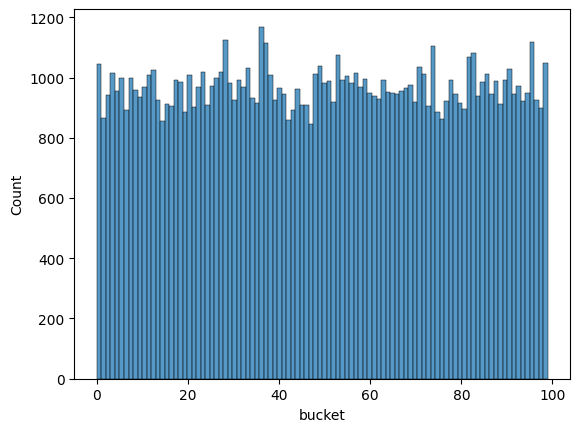

In [243]:
f_test['bucket'] = f_test['user_id'].apply(lambda x: int(hashlib.md5((str(x) + 'my_salt').encode()).hexdigest(), 16) % 100)

sns.histplot(f_test.bucket, bins=100)
plt.show()

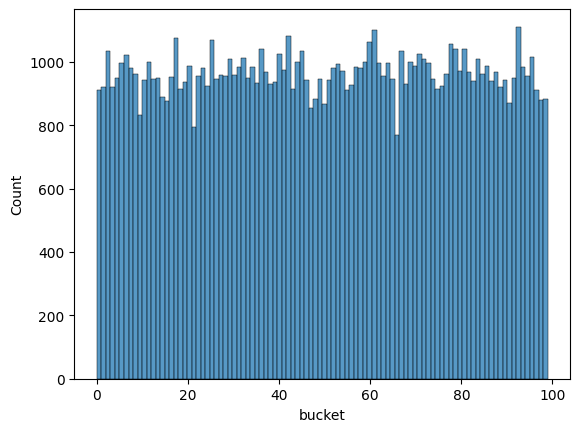

In [244]:
f_control['bucket'] = f_control['user_id'].apply(lambda x: int(hashlib.md5((str(x) + 'my_salt').encode()).hexdigest(), 16) % 100)

sns.histplot(f_control.bucket, bins=100)
plt.show()

In [426]:
f_control.head()

,user_id,timestamp_view,is_hit,exp_group,bucket
18,217,1654307886,True,control,90
19,217,1655125996,True,control,90
20,221,1654050177,True,control,78
21,221,1654094486,True,control,78
22,221,1654446360,True,control,78


In [427]:
f_test.head()

,user_id,timestamp_view,is_hit,exp_group,bucket
0,200,1655009047,True,test,32
1,201,1654043283,False,test,59
2,201,1654173790,False,test,59
3,201,1654444704,True,test,59
4,201,1654517459,False,test,59


In [ ]:
# На сколько п.п. метрика в test выше?
((f_test['is_hit']).mean() - (f_control['is_hit']).mean()) * 100

np.float64(1.317765109389002)

In [251]:
f_control_bucketed = f_control.groupby(['bucket'])['is_hit'].mean()

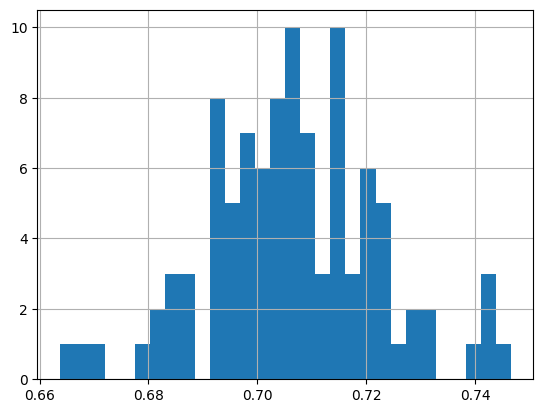

In [276]:
f_control_bucketed.hist(bins=30);

In [256]:
f_test_bucketed = f_test.groupby(['bucket'])['is_hit'].mean()

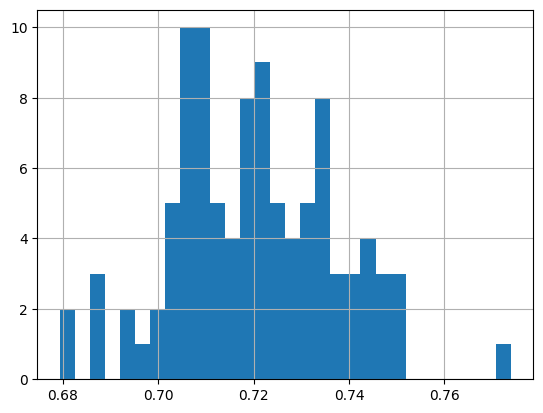

In [279]:
f_test_bucketed.hist(bins=30);

In [280]:
from scipy.stats import ttest_ind

ttest_ind(f_test_bucketed, f_control_bucketed, equal_var=False, alternative='two-sided')

TtestResult(statistic=np.float64(5.7904570733445135), pvalue=np.float64(2.7328215543449722e-08), df=np.float64(197.2139256573149))

In [274]:
from scipy.stats import mannwhitneyu

mannwhitneyu(f_test_bucketed, f_control_bucketed, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(7250.0), pvalue=np.float64(3.876018970118259e-08))

In [429]:
# Центр mannwhitneyu
(len(f_test_bucketed) * len(f_control_bucketed)) / 2

5000.0

*Различие статистически значимо, p-value < 0.05 в обоих критериях*